# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

df = pd.read_csv("bread_basket.csv")
df.head()

,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [43]:
df.dtypes

,0
transaction,int64
item,object
date_time,object
time,object
period_day,object
weekday_weekend,object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [44]:
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

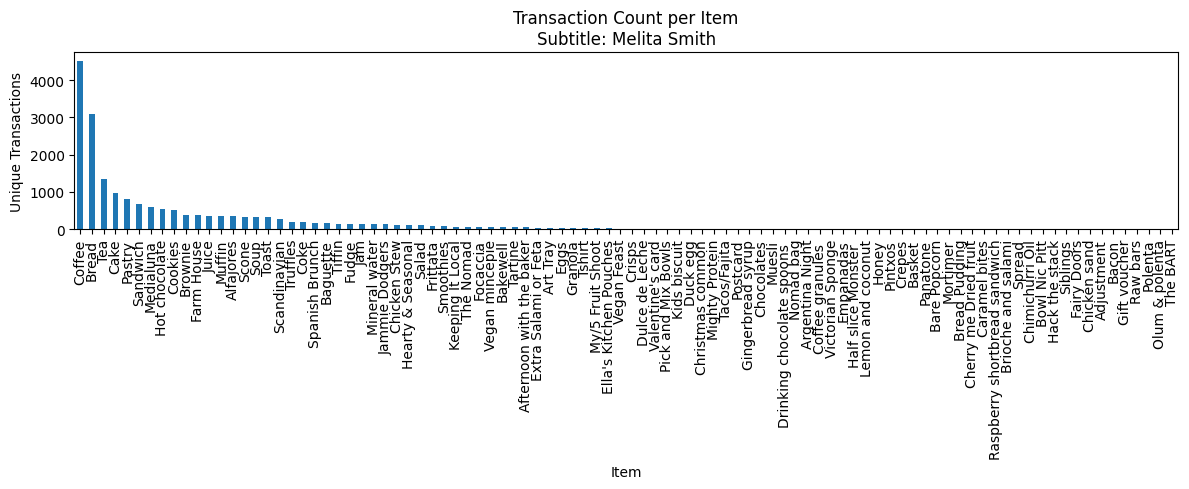

In [45]:

subtitle = "Melita Smith"
item_counts = df.groupby('item')['transaction'].nunique().sort_values(ascending=False)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [46]:
print("Counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew:")
print(df['item'].value_counts()[['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']])

Counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew:
item
Coffee          5471
Tea             1435
Alfajores        369
Juice            369
Chicken Stew     123
Name: count, dtype: int64


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [48]:
transactions = df.groupby('transaction')['item'].apply(list)
te=TransactionEncoder()
te_ary=te.fit(transactions).transform(transactions)
basket_df=pd.DataFrame(te_ary, columns=te.columns_)


freq_fp = fpgrowth(basket_df, min_support=0.2, use_colnames=True)
freq_fp.sort_values('support', ascending=False)
freq_fp.head()

,support,itemsets
0,0.327205,(Bread)
1,0.478394,(Coffee)


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [83]:
rules = association_rules(freq_fp, metric='confidence', min_threshold=0.1)
print(rules[['antecedents','consequents','support','confidence','lift']].sort_values('confidence', ascending=False))

if rules.empty: print("No rules found.")

        antecedents consequents   support  confidence      lift
17          (Toast)    (Coffee)  0.023666    0.704403  1.472431
6       (Medialuna)    (Coffee)  0.035182    0.569231  1.189878
4          (Pastry)    (Coffee)  0.047544    0.552147  1.154168
10          (Juice)    (Coffee)  0.020602    0.534247  1.116750
16       (Sandwich)    (Coffee)  0.038246    0.532353  1.112792
12           (Cake)    (Coffee)  0.054728    0.526958  1.101515
3         (Cookies)    (Coffee)  0.028209    0.518447  1.083723
2   (Hot chocolate)    (Coffee)  0.029583    0.507246  1.060311
8             (Tea)    (Coffee)  0.049868    0.349630  0.730840
5          (Pastry)     (Bread)  0.029160    0.338650  1.034977
1           (Bread)    (Coffee)  0.090016    0.275105  0.575059
14           (Cake)       (Tea)  0.023772    0.228891  1.604781
15           (Cake)     (Bread)  0.023349    0.224822  0.687097
9             (Tea)     (Bread)  0.028104    0.197037  0.602181
0          (Coffee)     (Bread)  0.09001

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:*

*   Support - 95/11569 transcations contain Coffee, Cake, and Bread together.
*   Confidence - 18.3%
*   Lift>1 - Althogh that implies a a positive association, the lift for this is <1. The association is negative. Buying Coffee and Cake makes you less likely to buy Bread.

>